# Explore here

In [31]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials
import seaborn as sns


# load the .env file variables
load_dotenv()
client_id = os.environ.get("CLIENT_ID")
client_secret = os.environ.get("CLIENT_SECRET")

auth_manager = SpotifyClientCredentials(client_id=client_id, client_secret=client_secret)
spotify = spotipy.Spotify(auth_manager=auth_manager)

spotify

In [45]:
artist_id = "7xeM7V59cA1X8GKyKKQV87"

# Get the top tracks of an artist
results = spotify.artist_top_tracks(artist_id)
tracks= results["tracks"]
data = pd.DataFrame(tracks)

In [41]:
data[["name","popularity","duration_ms"]]
data["duration_min"]=round(data["duration_ms"]/60000,2)        
data[["name","popularity","duration_min"]]


,name,popularity,duration_min
0,Que Lloro,76,4.01
1,Mientes Tan Bien,74,3.79
2,Entra en Mi Vida,72,4.15
3,Kilómetros,67,3.69
4,Sirena,65,4.45
5,Te Vi Venir,65,3.25
6,Suelta Mi Mano,66,4.01
7,Que Me Alcance la Vida,65,3.81
8,En Ésta No,65,3.89
9,Si Tú No Estás,60,3.76


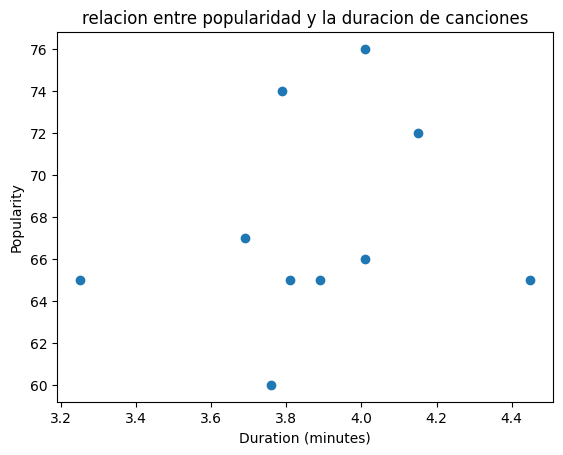

In [29]:
x=data["duration_min"]
y=data["popularity"]
plt.scatter(x,y)
plt.xlabel('Duration (minutes)')
plt.ylabel('Popularity')
plt.title('relacion entre popularidad y la duracion de canciones')
plt.show()

Se observa que los datos estan un poco dispersos, la duracion de canciones entre 3.6 min y 4.min tienen distinta  popularidad, tambien se observa que  para dos canciones que tienen 3.2 min y 4.4 minutos la popularidad es la misma, bajo el gráfico obtenido podria concluir que que la duración de las canciones no influye sobre la popularidad de las mismas, por otro lado se tienen muy pocas muestras para tener una conclusión precisa 

Para comprobar si los datos de duración en minutos influye sobre la popularidad de la canción se hace un estudio de la correlación entre ellos

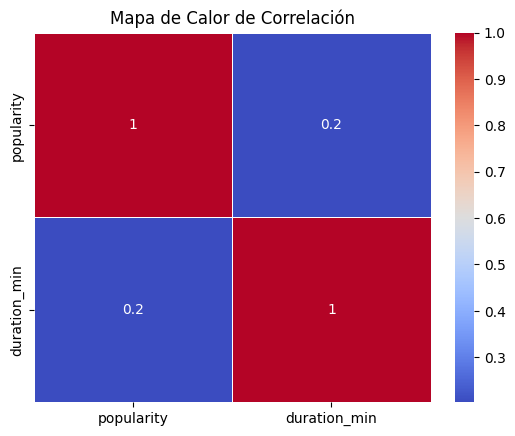

In [33]:
new_data = data[["popularity","duration_min"]]
corr = new_data.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Mapa de Calor de Correlación")
plt.show()

Conclusión: al analizar el mapa de correlaciones se concluye en que la duración de las canciones no influyen sobre el éxito de las mismas.